In [39]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import random
from zonolayer import compute_zonolayer_bounds
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from SLINN import SLINN, midrad

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Heating Load - Energy Dataset

In [40]:
df = pd.read_csv('Data/energy_efficiency_data.csv')
X = df.drop(columns=['Heating_Load', 'Cooling_Load'])
y_heating = df['Heating_Load'].values

def intervalise_heating_load(y):
    n = len(y)
    r = np.abs(np.random.normal(loc=0.5, scale=0.25, size=n))
    b = np.random.uniform(low=-1.0, high=1.0, size=n)
    m = y - r + (1 + b) * r
    return pd.DataFrame({"y": y, "y_lower": m - r, "y_upper": m + r})

intervals = intervalise_heating_load(y_heating)

# Split and Normalize
X_train, X_test, y_low_tr, y_low_te, y_up_tr, y_up_te = train_test_split(
    X.values, intervals['y_lower'].values, intervals['y_upper'].values, test_size=0.25, random_state=42
)

X_min, X_max = X_train.min(axis=0), X_train.max(axis=0)
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)
y_mid_tr, y_rad_tr = (y_low_tr + y_up_tr) / 2, (y_up_tr - y_low_tr) / 2
y_mean, y_std = y_mid_tr.mean(), y_mid_tr.std()
Y_train = midrad((y_mid_tr.reshape(-1,1) - y_mean) / y_std, y_rad_tr.reshape(-1,1) / y_std)

# Normalise both bounds
y_low_tr = (y_low_tr - y_mean) / y_std
y_up_tr  = (y_up_tr  - y_mean) / y_std

class RegressionNetwork(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=8, zono_dim=8):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, zono_dim)
        )
        self.regressor = nn.Linear(hidden_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        if return_features:
            return out, features
        return out


def train_centre(x_t, y_lb_t, y_ub_t, epochs=7000, lr=0.01, print_every=50):
    y_mid = ((y_lb_t + y_ub_t) / 2).reshape(-1, 1)
    
    centre_net = RegressionNetwork(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        pred = centre_net(x_t) 
        loss = criterion(pred, y_mid)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")
    return centre_net

def extract_latent_features(model, x):
    model.eval()
    with torch.no_grad():
        preds, features = model(x, return_features=True)
    return preds.cpu().numpy(), features.cpu().numpy()

x_t = torch.tensor(X_train, dtype=torch.float32)
y_lb_t = torch.tensor(y_low_tr, dtype=torch.float32)
y_ub_t = torch.tensor(y_up_tr, dtype=torch.float32)

# Zonolayer computation
centre_net = train_centre(x_t, y_lb_t, y_ub_t)
pred_train, latent_train = extract_latent_features(centre_net, x_t)
pred_test, latent_test = extract_latent_features(centre_net, torch.tensor(X_test, dtype=torch.float32))
zonolayer = compute_zonolayer_bounds(latent_train, y_low_tr, y_up_tr, latent_test)

net = SLINN(nn_input_dim=X_train.shape[1], nn_hdim=8, nn_output_dim=1, L=2, L_rate=0.01, Beta=0.96)
print("Training SLINN...")
net.train(X_train, Y_train, epochs=7000)
pred = net.predict(X_test, Y_train)


Epoch 50: MSE = 0.113336
Epoch 100: MSE = 0.082019
Epoch 150: MSE = 0.075378
Epoch 200: MSE = 0.073058
Epoch 250: MSE = 0.069835
Epoch 300: MSE = 0.065498
Epoch 350: MSE = 0.061647
Epoch 400: MSE = 0.053725
Epoch 450: MSE = 0.042184
Epoch 500: MSE = 0.034479
Epoch 550: MSE = 0.029677
Epoch 600: MSE = 0.011256
Epoch 650: MSE = 0.009225
Epoch 700: MSE = 0.008797
Epoch 750: MSE = 0.008556
Epoch 800: MSE = 0.008336
Epoch 850: MSE = 0.008127
Epoch 900: MSE = 0.013715
Epoch 950: MSE = 0.007802
Epoch 1000: MSE = 0.007608
Epoch 1050: MSE = 0.007392
Epoch 1100: MSE = 0.007148
Epoch 1150: MSE = 0.011701
Epoch 1200: MSE = 0.006750
Epoch 1250: MSE = 0.006478
Epoch 1300: MSE = 0.006187
Epoch 1350: MSE = 0.005886
Epoch 1400: MSE = 0.006215
Epoch 1450: MSE = 0.005555
Epoch 1500: MSE = 0.005321
Epoch 1550: MSE = 0.005118
Epoch 1600: MSE = 0.004935
Epoch 1650: MSE = 0.004772
Epoch 1700: MSE = 0.004886
Epoch 1750: MSE = 0.004753
Epoch 1800: MSE = 0.004507
Epoch 1850: MSE = 0.004400
Epoch 1900: MSE = 0.0

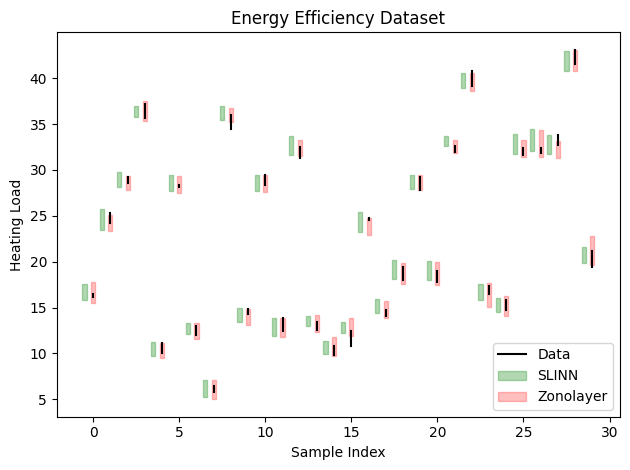

In [41]:
# Denormalise for plotting
yl_zl = zonolayer["y_lower"] * y_std + y_mean
yu_zl = zonolayer["y_upper"] * y_std + y_mean
midpoint_model = zonolayer["midpoint"] * y_std + y_mean
y_p_mid = (pred.mid.flatten() * y_std) + y_mean
y_p_rad = pred.rad.flatten() * y_std

n_plot = 30
idx = np.sort(np.random.choice(len(X_test), n_plot, replace=False))

plt.figure()

slinn_offset = -0.50   # Shift Left

width = 0.12

for i, val in enumerate(idx):

    # True interval
    plt.plot(
        [i, i],
        [y_low_te[val], y_up_te[val]],
        color='black',
        lw=1.5,
        zorder=3,
        label='Data' if i == 0 else ""
    )

    plt.fill_between(
        [i - width + slinn_offset, i + width + slinn_offset],
        y_p_mid[val] - y_p_rad[val],
        y_p_mid[val] + y_p_rad[val],
        color='green',
        alpha=0.3,
        label='SLINN' if i == 0 else ""
    )

    # ZonoLayer interval
    plt.fill_between(
        [i - width, i + width],
        yl_zl[val],
        yu_zl[val],
        color='red',
        alpha=0.25,
        label='Zonolayer' if i == 0 else ""
    )

# plt.scatter(
#     [i for i in range(n_plot)], 
#     midpoint_model[idx], 
#     marker='+', color='red', zorder=5, s=80, label='ZonoLayer Midpoint'
# )

plt.title("Energy Efficiency Dataset")
plt.xlabel("Sample Index")
plt.ylabel("Heating Load")
plt.legend()
plt.tight_layout()
plt.savefig("HeatingLoad.pdf", bbox_inches="tight")
plt.show()

## Concrete Compressive Strength

In [42]:
concrete_compressive_strength = fetch_ucirepo(id=165) 
X = concrete_compressive_strength.data.features 
y = concrete_compressive_strength.data.targets 

def intervalise_cc_strength(y):
    y = np.asarray(y).reshape(-1) 
    delta = np.abs(np.random.normal(loc=2.0, scale=1.0, size=len(y)))
    b = np.random.uniform(low=-1.0, high=1.0, size=len(y))
    m = y + b * delta

    return pd.DataFrame({
        "y": y,
        "y_lower": m - delta,
        "y_upper": m + delta
    })
intervals = intervalise_cc_strength(y)

# Split and Normalize
X_train, X_test, y_low_tr, y_low_te, y_up_tr, y_up_te = train_test_split(
    X.values, intervals['y_lower'].values, intervals['y_upper'].values, test_size=0.3, random_state=42
)

X_min, X_max = X_train.min(axis=0), X_train.max(axis=0)
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

# Mid/radius
y_mid_tr = (y_low_tr + y_up_tr) / 2
y_rad_tr = (y_up_tr - y_low_tr) / 2

# Min-max scaling parameters from training intervals
y_min = y_low_tr.min()
y_max = y_up_tr.max()

# Scale bounds to [0,1]
y_low_tr = (y_low_tr - y_min) / (y_max - y_min)
y_up_tr  = (y_up_tr  - y_min) / (y_max - y_min)

# Recompute midpoint/radius after scaling
y_mid_tr = (y_low_tr + y_up_tr) / 2
y_rad_tr = (y_up_tr - y_low_tr) / 2

Y_train = midrad(
    y_mid_tr.reshape(-1,1),
    y_rad_tr.reshape(-1,1)
)

In [43]:
class CentreNet(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=24, zono_dim=8):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, zono_dim)
        )
        self.regressor = nn.Linear(zono_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        if return_features:
            return out, features
        return out


def train_centre(x_t, y_lb_t, y_ub_t, epochs=12000, lr=0.005, print_every=50):
    y_mid = ((y_lb_t + y_ub_t) / 2).reshape(-1, 1)
    
    centre_net = CentreNet(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        pred = centre_net(x_t) 
        loss = criterion(pred, y_mid)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")
    return centre_net


x_t = torch.tensor(X_train, dtype=torch.float32)
y_lb_t = torch.tensor(y_low_tr, dtype=torch.float32)
y_ub_t = torch.tensor(y_up_tr, dtype=torch.float32)

# Zonolayer computation
centre_net = train_centre(x_t, y_lb_t, y_ub_t)
pred_train, latent_train = extract_latent_features(centre_net, x_t)
pred_test, latent_test = extract_latent_features(centre_net, torch.tensor(X_test, dtype=torch.float32))

zonolayer = compute_zonolayer_bounds(latent_train, y_low_tr, y_up_tr, latent_test)


# Denormalise for plotting
yl_zl = zonolayer["y_lower"] * (y_max - y_min) + y_min
yu_zl = zonolayer["y_upper"] * (y_max - y_min) + y_min
midpoint_model = zonolayer["midpoint"] * (y_max - y_min) + y_min

net = SLINN(nn_input_dim=X_train.shape[1], nn_hdim=24, nn_output_dim=1, L=3, L_rate=0.005, Beta=0.96)
print("Training SLINN...")
net.train(X_train, Y_train, epochs=12000)

# Predict & Denormalize
pred = net.predict(X_test, Y_train)
y_p_mid = pred.mid.flatten() * (y_max - y_min) + y_min
y_p_rad = pred.rad.flatten() * (y_max - y_min)

Epoch 50: MSE = 0.016150
Epoch 100: MSE = 0.014214
Epoch 150: MSE = 0.013640
Epoch 200: MSE = 0.012557
Epoch 250: MSE = 0.009935
Epoch 300: MSE = 0.007999
Epoch 350: MSE = 0.007074
Epoch 400: MSE = 0.006392
Epoch 450: MSE = 0.005986
Epoch 500: MSE = 0.005800
Epoch 550: MSE = 0.005742
Epoch 600: MSE = 0.005673
Epoch 650: MSE = 0.005624
Epoch 700: MSE = 0.005582
Epoch 750: MSE = 0.005669
Epoch 800: MSE = 0.005532
Epoch 850: MSE = 0.005501
Epoch 900: MSE = 0.005472
Epoch 950: MSE = 0.005787
Epoch 1000: MSE = 0.005440
Epoch 1050: MSE = 0.005411
Epoch 1100: MSE = 0.005383
Epoch 1150: MSE = 0.008365
Epoch 1200: MSE = 0.005367
Epoch 1250: MSE = 0.005325
Epoch 1300: MSE = 0.005295
Epoch 1350: MSE = 0.005265
Epoch 1400: MSE = 0.005271
Epoch 1450: MSE = 0.005275
Epoch 1500: MSE = 0.005216
Epoch 1550: MSE = 0.005185
Epoch 1600: MSE = 0.005155
Epoch 1650: MSE = 0.005126
Epoch 1700: MSE = 0.005095
Epoch 1750: MSE = 0.005210
Epoch 1800: MSE = 0.005076
Epoch 1850: MSE = 0.005032
Epoch 1900: MSE = 0.0

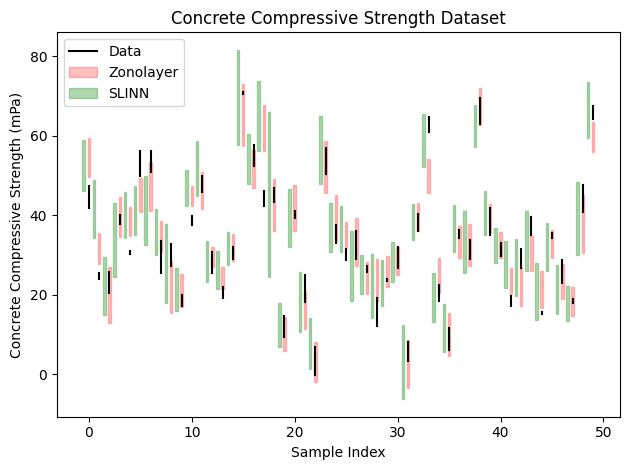

In [44]:
n_plot = 50
idx = np.sort(np.random.choice(len(X_test), n_plot, replace=False))

plt.figure()

slinn_offset = -0.50

width = 0.12 

for i, val in enumerate(idx):
    plt.plot(
        [i, i],
        [y_low_te[val], y_up_te[val]],
        color='black',
        lw=1.5,
        zorder=3,
        label='Data' if i == 0 else ""
    )

    plt.fill_between(
        [i - width, i + width],
        yl_zl[val],
        yu_zl[val],
        color='red',
        alpha=0.25,
        label='Zonolayer' if i == 0 else ""
    )

    plt.fill_between(
        [i - width + slinn_offset, i + width + slinn_offset],
        y_p_mid[val] - y_p_rad[val],
        y_p_mid[val] + y_p_rad[val],
        color='green',
        alpha=0.3,
        label='SLINN' if i == 0 else ""
    )

plt.title("Concrete Compressive Strength Dataset")
plt.xlabel("Sample Index")
plt.ylabel("Concrete Compressive Strength (mPa)")
plt.legend()
plt.tight_layout()
plt.savefig("CCStrength.pdf", bbox_inches="tight")
plt.show()

### Air Quality

In [45]:
def intervalise_airq(y):
    y = np.asarray(y).reshape(-1)
    delta = np.abs(np.random.normal(loc=2.0, scale=1.0, size=len(y)))
    b = np.random.uniform(low=-1.0, high=1.0, size=len(y))
    m = y + b * delta
    return pd.DataFrame({
        "y": y,
        "y_lower": m - delta,
        "y_upper": m + delta
    })


air_quality = fetch_ucirepo(id=360)

X = air_quality.data.features
y_all = air_quality.data.targets
df = pd.concat([X, y_all], axis=1)

print(air_quality.metadata)
print(air_quality.variables)

df = df.replace(-200, np.nan)

# Target: true hourly Benzene concentration
df = df.dropna(subset=["C6H6(GT)"])

feature_cols = [
    "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
    "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"
]
df = df.dropna(subset=feature_cols)

scaler = StandardScaler()
X_norm = pd.DataFrame(
    scaler.fit_transform(df[feature_cols]),
    columns=feature_cols,
    index=df.index
)

y = df["C6H6(GT)"].values
interval_df = intervalise_airq(y).set_index(df.index)
full_df = pd.concat([X_norm, interval_df], axis=1)


y_min = full_df["y_lower"].min()
y_max = full_df["y_upper"].max()

full_df["y_lower_norm"] = (full_df["y_lower"] - y_min) / (y_max - y_min)
full_df["y_upper_norm"] = (full_df["y_upper"] - y_min) / (y_max - y_min)

train_df, test_df = train_test_split(full_df, test_size=0.2, random_state=42)

X_train = train_df[feature_cols].values
X_test = test_df[feature_cols].values
y_low_tr = train_df["y_lower_norm"].values
y_up_tr = train_df["y_upper_norm"].values
y_low_te = test_df["y_lower_norm"].values
y_up_te = test_df["y_upper_norm"].values



class CentreNet(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=12, zono_dim=8):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, zono_dim)
        )
        self.regressor = nn.Linear(zono_dim, 1)

    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        out = self.regressor(features)
        if return_features:
            return out, features
        return out


def train_centre(x_t, y_lb_t, y_ub_t, epochs=8000, lr=0.001, print_every=50):
    y_mid = ((y_lb_t + y_ub_t) / 2).reshape(-1, 1)
    centre_net = CentreNet(input_dim=x_t.shape[1])
    optimizer = torch.optim.Adam(centre_net.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        pred = centre_net(x_t)
        loss = criterion(pred, y_mid)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch+1}: MSE = {loss.item():.6f}")
    return centre_net


def extract_latent_features(model, x_t):
    """Run a forward pass, returning (point predictions, latent zono_dim features)."""
    model.eval()
    with torch.no_grad():
        pred, features = model(x_t, return_features=True)
    return pred.numpy().flatten(), features.numpy()


x_t = torch.tensor(X_train, dtype=torch.float32)
y_lb_t = torch.tensor(y_low_tr, dtype=torch.float32)
y_ub_t = torch.tensor(y_up_tr, dtype=torch.float32)

centre_net = train_centre(x_t, y_lb_t, y_ub_t)

pred_train, latent_train = extract_latent_features(centre_net, x_t)
pred_test, latent_test = extract_latent_features(centre_net, torch.tensor(X_test, dtype=torch.float32))

zonolayer = compute_zonolayer_bounds(latent_train, y_low_tr, y_up_tr, latent_test)


yl_zl = zonolayer["y_lower"] * (y_max - y_min) + y_min
yu_zl = zonolayer["y_upper"] * (y_max - y_min) + y_min
midpoint_model = zonolayer["midpoint"] * (y_max - y_min) + y_min


net = SLINN(nn_input_dim=X_train.shape[1], nn_hdim=12, nn_output_dim=1, L=3, L_rate=0.001, Beta=0.96)
print("Training SLINN...")

y_mid_tr = (y_low_tr + y_up_tr) / 2
y_rad_tr = (y_up_tr - y_low_tr) / 2

Y_train = midrad(
    y_mid_tr.reshape(-1,1),
    y_rad_tr.reshape(-1,1)
)
net.train(X_train, Y_train, epochs=8000)
pred = net.predict(X_test, Y_train)
y_p_mid = pred.mid.flatten() * (y_max - y_min) + y_min
y_p_rad = pred.rad.flatten() * (y_max - y_min)

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

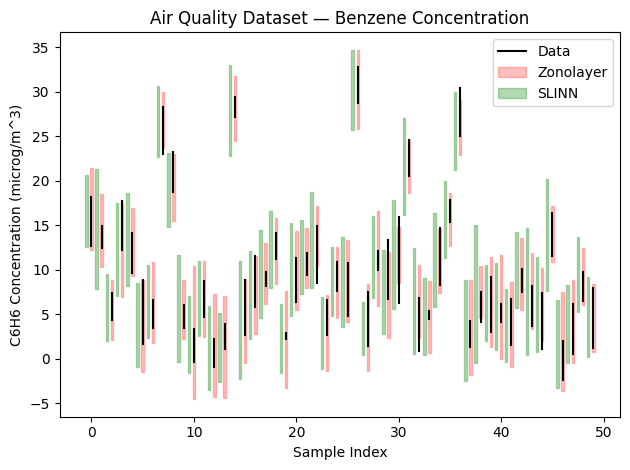

In [46]:
y_low_te_denorm = y_low_te * (y_max - y_min) + y_min
y_up_te_denorm = y_up_te * (y_max - y_min) + y_min

n_plot = 50
idx = np.sort(np.random.choice(len(X_test), n_plot, replace=False))

plt.figure()

slinn_offset = -0.50
width = 0.12

for i, val in enumerate(idx):
    plt.plot(
        [i, i],
        [y_low_te_denorm[val], y_up_te_denorm[val]],
        color='black',
        lw=1.5,
        zorder=3,
        label='Data' if i == 0 else ""
    )

    plt.fill_between(
        [i - width, i + width],
        yl_zl[val],
        yu_zl[val],
        color='red',
        alpha=0.25,
        label='Zonolayer' if i == 0 else ""
    )

    plt.fill_between(
        [i - width + slinn_offset, i + width + slinn_offset],
        y_p_mid[val] - y_p_rad[val],
        y_p_mid[val] + y_p_rad[val],
        color='green',
        alpha=0.3,
        label='SLINN' if i == 0 else ""
    )

plt.title("Air Quality Dataset — Benzene Concentration")
plt.xlabel("Sample Index")
plt.ylabel("C6H6 Concentration (microg/m^3)")
plt.legend()
plt.tight_layout()
plt.savefig("AirQualityBenzene.pdf", bbox_inches="tight")
plt.show()